In [1]:
### IMPORT

# lettuce
import lettuce as lt
# unit conversion...

# os and data management
import datetime
import os, shutil
# from pyevtk.hl import imageToVTK
from glob import glob

# calculation
import numpy as np
# torch
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# plotting
import matplotlib
import matplotlib.pyplot as plt
#matplotlib.rcParams['agg.path.chunksize'] = 1000

matplotlib.style.use('../figure_style.mplstyle')

In [2]:
### DATA I/O settings
data_base_path = "/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data"


In [3]:
# PARAMETERS

mas = [0.05] #[0.05, 0.1, 0.2]
res = [10000] #[10000, 20000, 35000]
gbcs = ['fwbb', 'hwbb'] #['fwbb', 'hwbb', 'ibb']


In [4]:
### CREATE PATH-DICT for all parameter-combinations and respective data on cluster/work/...

paths_dict_ref = dict()
paths_dict_reduced = dict()

for ma in mas:
    for re in res:
        for gbc in gbcs:
            paths_dict_reduced[ma,re,gbc] = []
            paths_dict_ref[ma,re,gbc] = []
            dir_names_reduced = glob(data_base_path + "/*plate_10x10x1PU_HL100_kbc_T20000_" + "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
            dir_names_ref = glob(data_base_path + "/*REF_plate_full_HL100_kbc_T20000_" + "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
            
            if len(dir_names_reduced)>1:
                print("(!) Warning: more than 1 simulation for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                print(dir_names_reduced)
            elif len(dir_names_reduced) == 1:
                # this is what we want: one unique simulation found
                paths_dict_reduced[ma,re,gbc].append(*dir_names_reduced)
            else:
                print("(!) Warning: no path found for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                
            if len(dir_names_ref)>1:
                print("(!) Warning: more than 1 simulation for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)
                print(dir_names_ref)
            elif len(dir_names_ref) == 1:
                # this is what we want: one unique simulation found
                paths_dict_ref[ma,re,gbc].append(*dir_names_ref)
            else:
                print("(!) Warning: no path found for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc)

In [5]:
### data_series identifiers

# x_positions:
x_positions = [1,2,3]
y_positions = [0,1,2,3]

data_file_prefix = "p_xyz"  # later change to "up_xyz", for sims. after 26.11.24 (!)

In [6]:
print(paths_dict_ref)

{(0.05, 10000, 'fwbb'): ['/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb'], (0.05, 10000, 'hwbb'): ['/home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Ghwbb']}


In [7]:
# load timeseries
# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5
pu_timeseries_dict_reduced = dict()
pu_timeseries_dict_ref = dict()

for ma in mas:
    for re in res:
        for gbc in gbcs:
            for x_position in x_positions:
                for y_position in y_positions:
                  #  print("loading:", "Ma"+str(ma),"Re"+str(re),"G"+gbc, "/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    
                    # search for string REF:
                    print("searching: ", paths_dict_ref[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    matches = glob(paths_dict_ref[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    if len(matches)>1:
                        print("(!) Warning: more than 1 simulation for REF:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc, "("+str(x_position)+" ," + str(y_position)+")")
                        print(matches)
                    elif len(matches) == 1:
                        # this is what we want: one unique simulation found
                        #OLD: paths_dict[ma,re,gbc].append(*dir_names)
                        pu_timeseries_dict_ref[ma,re,gbc,x_position,y_position] = np.loadtxt(*matches)

                    # serach for string REDUCED:
                    matches = glob(paths_dict_reduced[ma,re,gbc][0]+"/PU_point_report/"+data_file_prefix+"("+str(x_position)+", "+str(y_position)+",*).txt")
                    if len(matches)>1:
                        print("(!) Warning: more than 1 simulation for REDUCED:", "Ma" + str(ma)  + "_Re" + str(re) + "_G" + gbc, "("+str(x_position)+", " + str(y_position)+")")
                        print(matches)
                    elif len(matches) == 1:
                        # this is what we want: one unique simulation found
                        #OLD: paths_dict[ma,re,gbc].append(*dir_names)
                        pu_timeseries_dict_reduced[ma,re,gbc,x_position,y_position] = np.loadtxt(*matches)

searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 0,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 1,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 2,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(1, 3,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gfwbb/PU_point_report/p_xyz(2, 0,*).txt
searching:  /home/mbille/Documents/cluster_hbrs_work/21_LBM/01_data/241120_135155-h3d_REF_plate_full_HL100_kbc_T20000_Ma0.05_Re10000_Gf

In [8]:
#pu_timeseries_dict_reduced.keys()
plt.close('all')


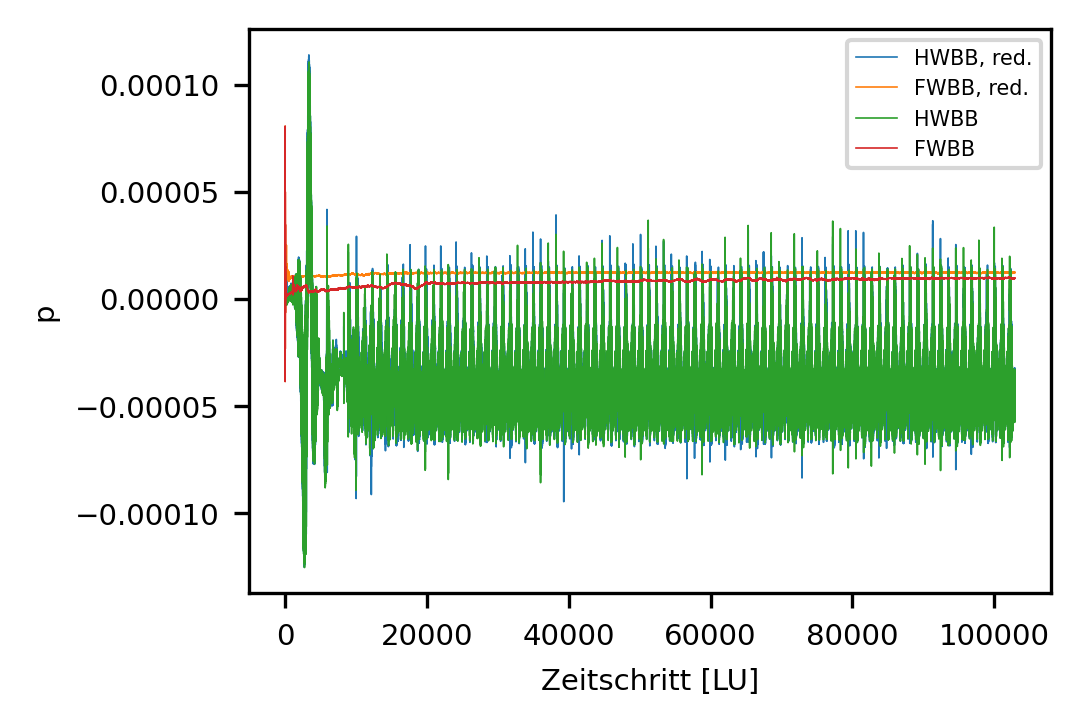

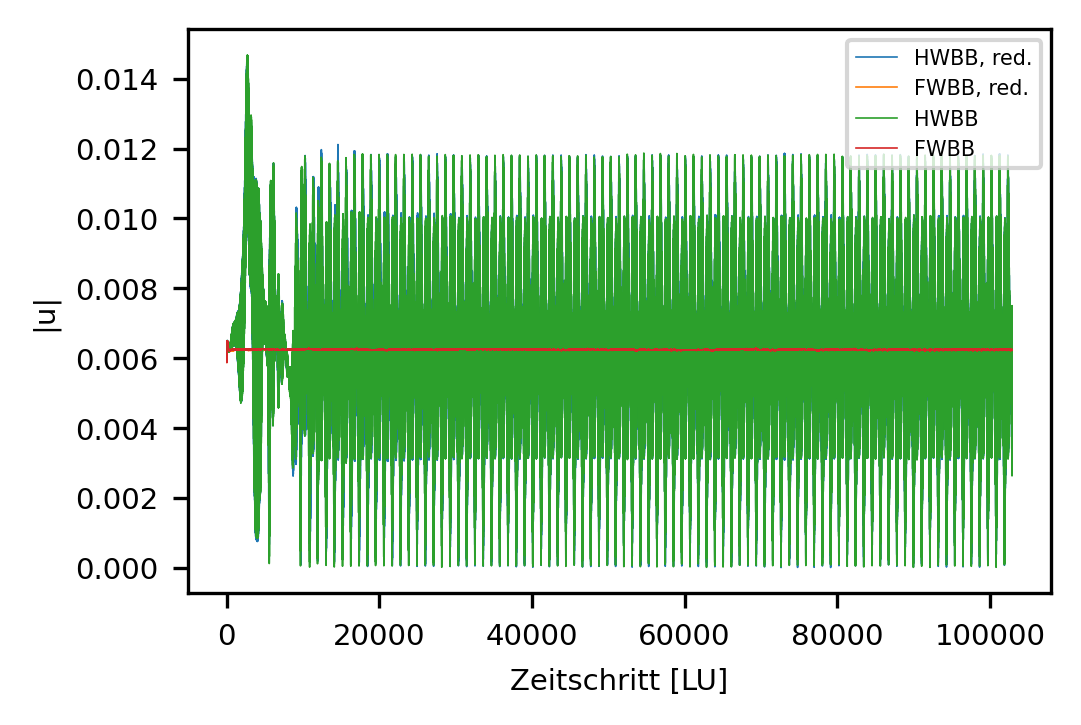

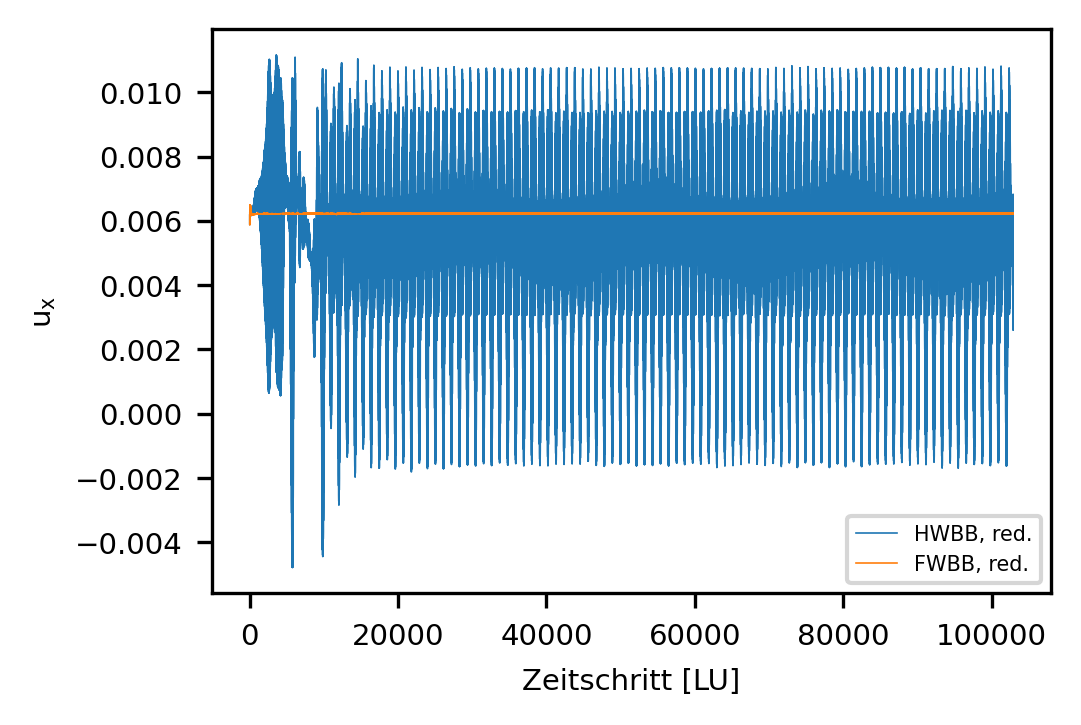

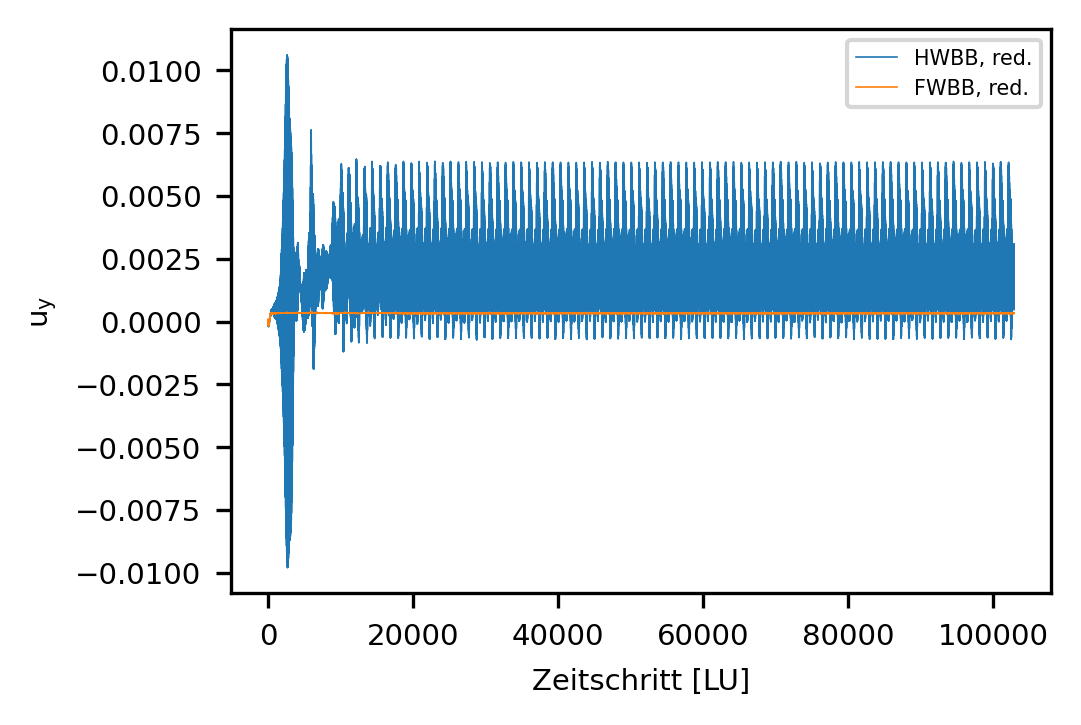

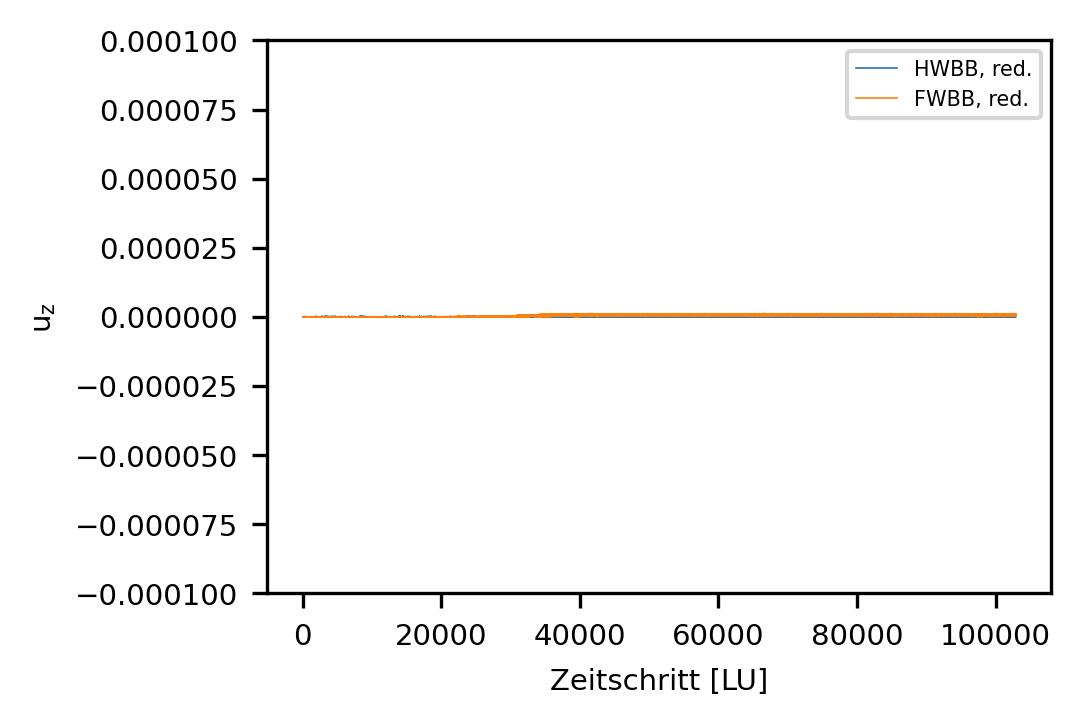

In [9]:
ma = 0.05
re = 10000
gbc = ""
x_position = 3
y_position = 3

plot_title = False

plotting_batch_label = "plate_"  # put as prefix to name before saving...

# xlims = [[99900,100200], [99000,102000]]  # see below

# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5

p_fig, p_axs = plt.subplots()
p_axs.plot(pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB, red.")
p_axs.plot(pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="FWBB, red.")
p_axs.plot(pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB")
p_axs.plot(pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="FWBB")

p_axs.set_xlabel("Zeitschritt [LU]")
#OLD: ax.set_ylim([0.7,1.7])  #TODO: mal "get" das Limit und dann mit 1e-4 vergleichen und das niedrigere nehmen.
#p_axs.set_xlim(left=100)
#p_axs.set_xlim([99900,100200])  # full, 99900-100200, 99000-102000
p_axs.set_ylabel("p")
p_axs.legend(fontsize=5)
if plot_title:
    plt.suptitle("p(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + " _at " + "LU("+str(x_position)+" ," + str(y_position)+")")
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "p(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
plt.show()
#plt.close(p_fig)


# u_mag
u_fig, u_axs = plt.subplots()

data_ref_hwbb = pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position]
data_reduced_hwbb = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
data_ref_fwbb = pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position]
data_reduced_fwbb = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]

# reduced HWBB vs. FWBB
u_axs.plot(data_reduced_hwbb[:,0], np.sqrt(np.square(data_reduced_hwbb[:, 3]) + np.square(data_reduced_hwbb[:, 4]) + np.square(data_reduced_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB, red.")
u_axs.plot(data_reduced_fwbb[:,0], np.sqrt(np.square(data_reduced_fwbb[:, 3]) + np.square(data_reduced_fwbb[:, 4]) + np.square(data_reduced_fwbb[:, 5])), marker="", linewidth=0.4, label="FWBB, red.")
# full HWBB vs. FWBB
u_axs.plot(data_ref_hwbb[:,0], np.sqrt(np.square(data_ref_hwbb[:, 3]) + np.square(data_ref_hwbb[:, 4]) + np.square(data_ref_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB")
u_axs.plot(data_ref_fwbb[:,0], np.sqrt(np.square(data_ref_fwbb[:, 3]) + np.square(data_ref_fwbb[:, 4]) + np.square(data_ref_fwbb[:, 5])), marker="", linewidth=0.4, label="FWBB")


u_axs.set_xlabel("Zeitschritt [LU]")
#u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#u_axs.set_xlim(left=100)
#u_axs.set_xlim([9000,11000])
#u_axs.set_xlim([99900,100200])
u_axs.set_ylabel("|u|")
u_axs.legend(fontsize=5)
if plot_title:
    plt.suptitle("u_mag(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_mag(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
plt.show()

# ux
u_fig, u_axs = plt.subplots()

data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="HWBB, red.")

data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="FWBB, red.")



u_axs.set_xlabel("Zeitschritt [LU]")
#u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#u_axs.set_xlim(left=100)
#u_axs.set_xlim([9000,11000])
#u_axs.set_xlim([99900,100200])
u_axs.set_ylabel(r"$\mathrm{u_x}$")
u_axs.legend(fontsize=5)
if plot_title:
    plt.suptitle("ux(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "ux(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
plt.show()

# uy
u_fig, u_axs = plt.subplots()

data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="HWBB, red.")

data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="FWBB, red.")



u_axs.set_xlabel("Zeitschritt [LU]")
#u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#u_axs.set_xlim(left=100)
#u_axs.set_xlim([9000,11000])
#u_axs.set_xlim([99900,100200])
u_axs.set_ylabel(r"$\mathrm{u_y}$")
u_axs.legend(fontsize=5)
if plot_title:
    plt.suptitle("uy(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "uy(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
plt.show()

# uz
u_fig, u_axs = plt.subplots()

data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="HWBB, red.")

data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
# u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
u_axs.plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="FWBB, red.")



u_axs.set_xlabel("Zeitschritt [LU]")
u_axs.set_ylim([-0.0001,0.0001])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
#u_axs.set_xlim(left=100)
#u_axs.set_xlim([9000,11000])
#u_axs.set_xlim([99900,100200])
u_axs.set_ylabel(r"$\mathrm{u_z}$")
u_axs.legend(fontsize=5)
if plot_title:
    plt.suptitle("uz(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "uz(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")" + ".png")
plt.show()

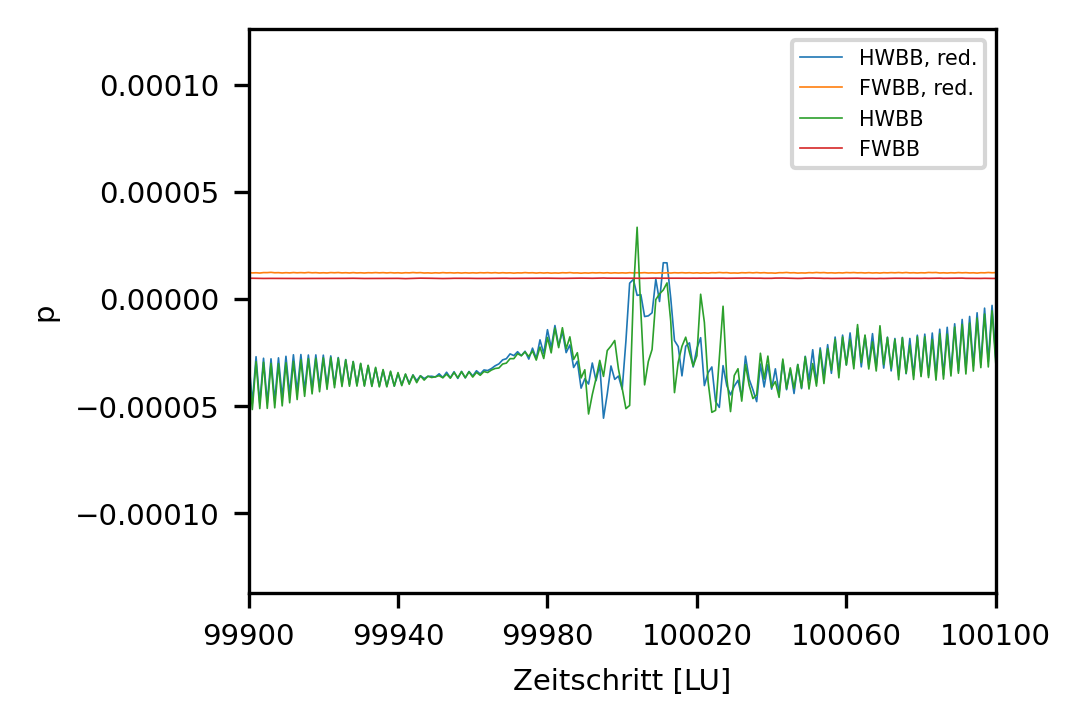

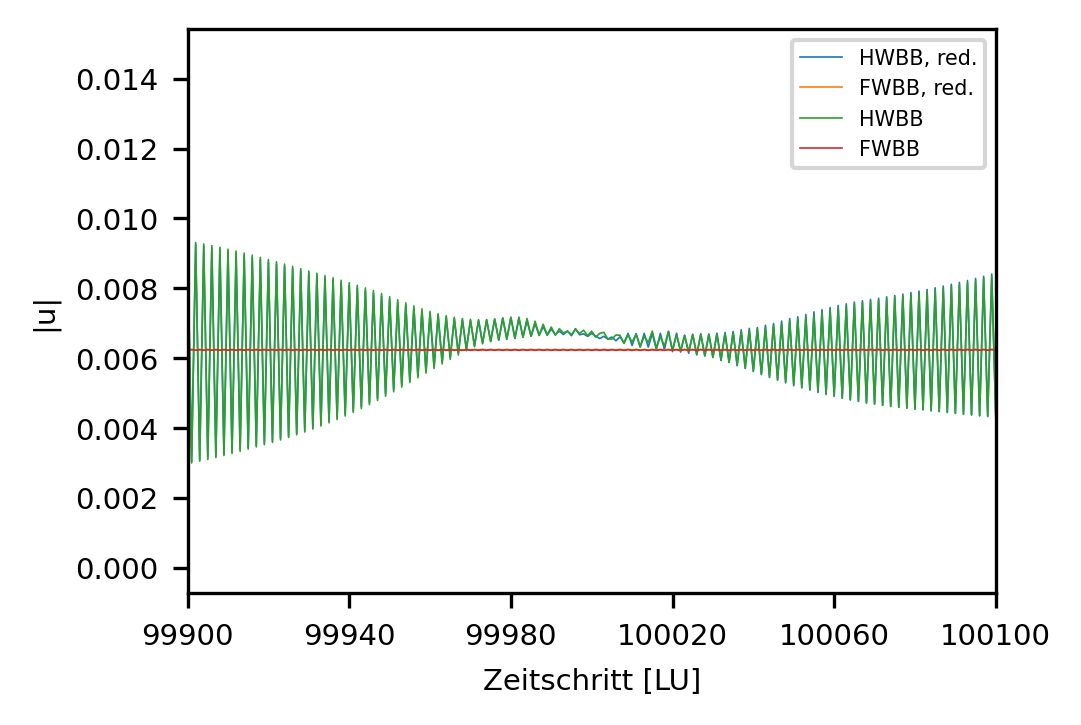

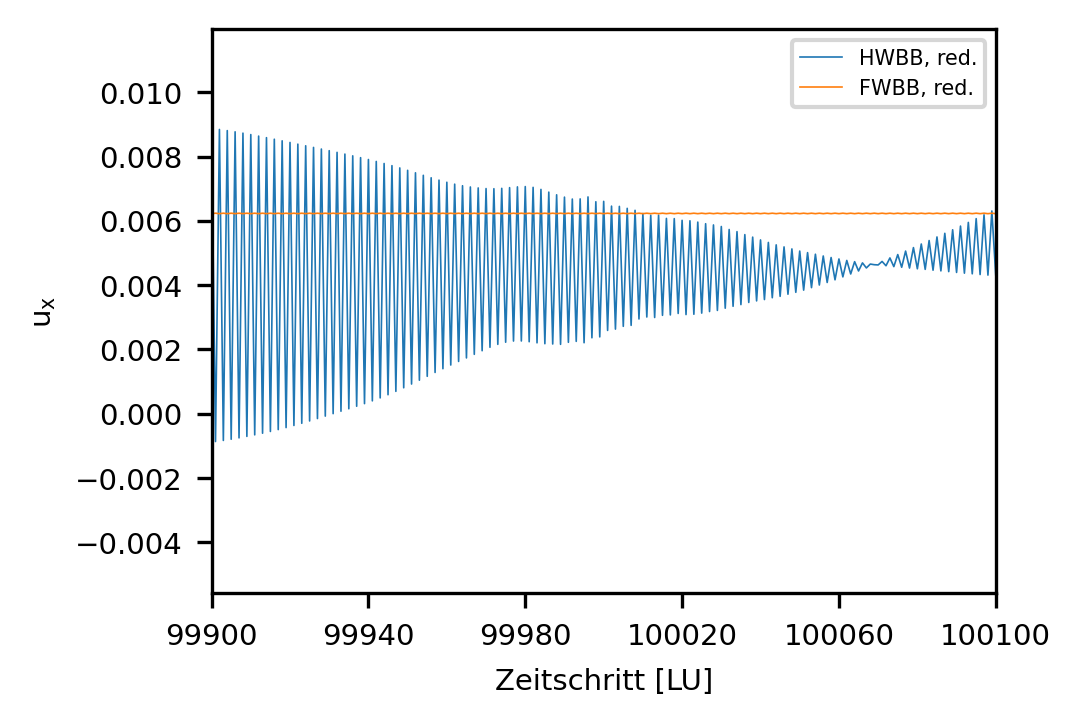

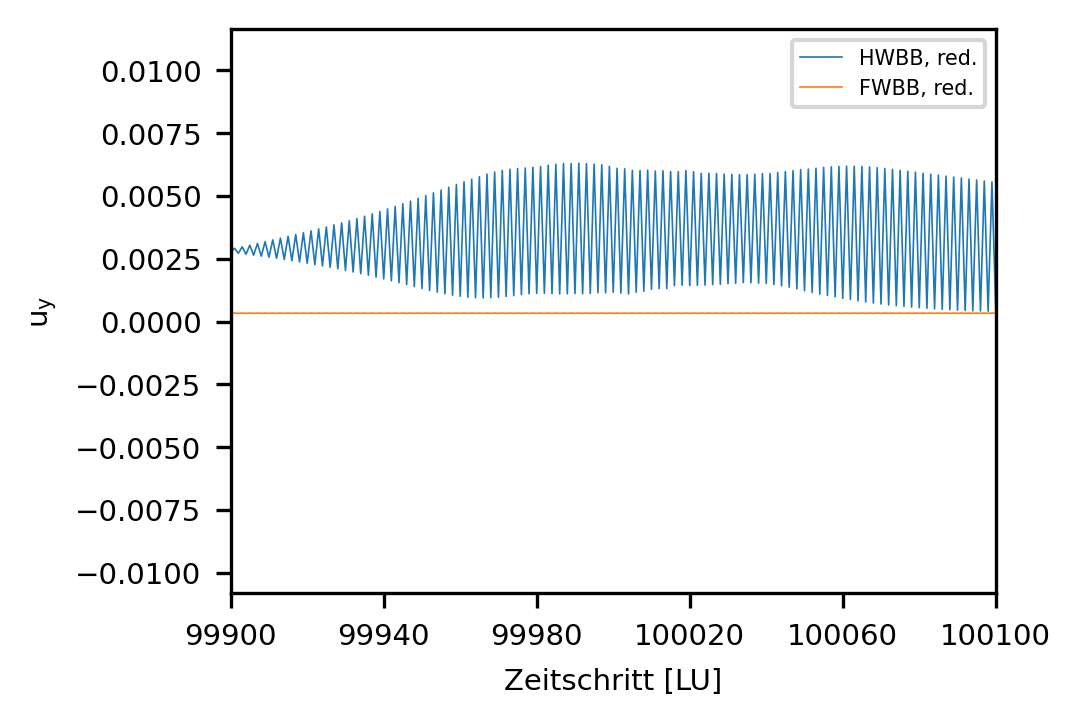

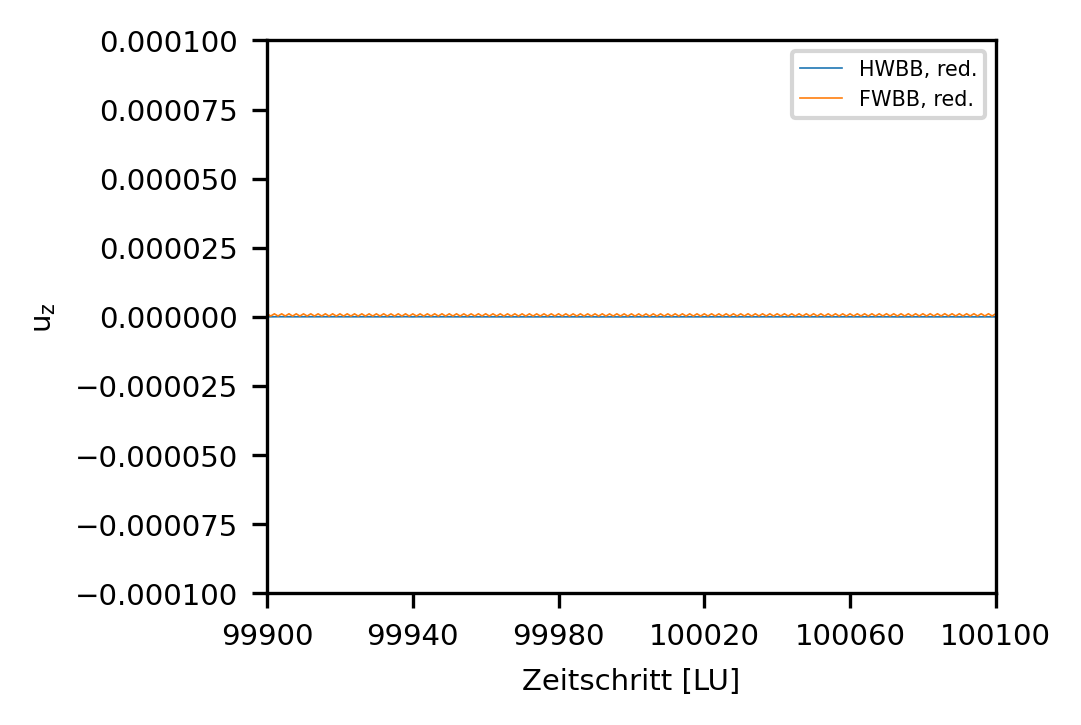

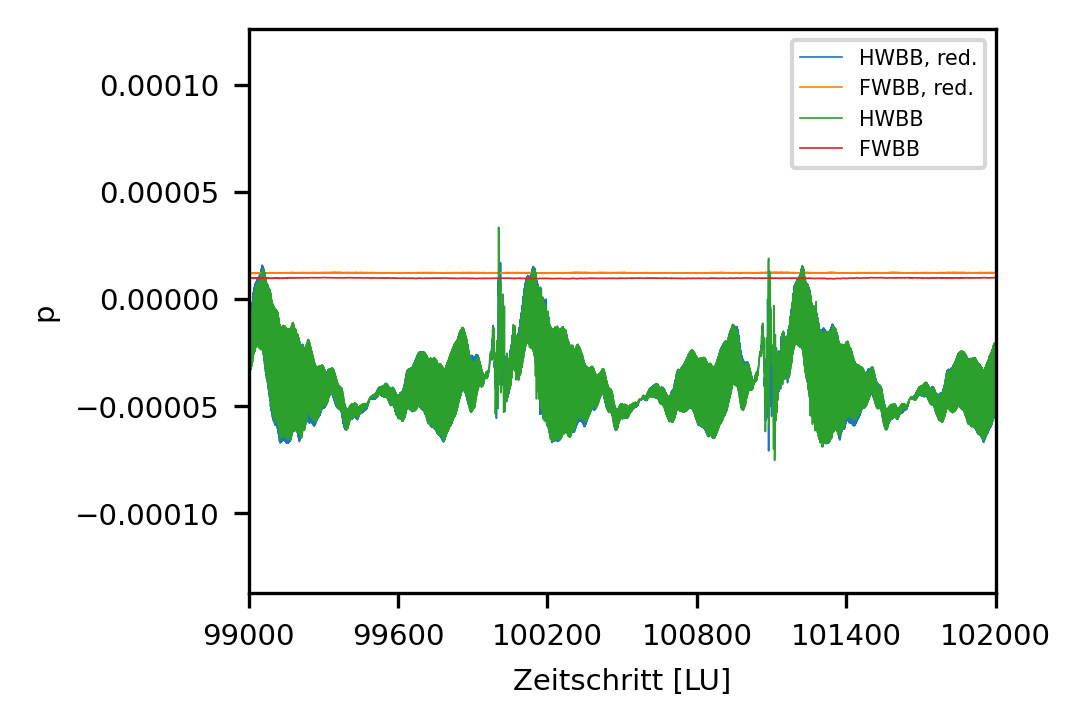

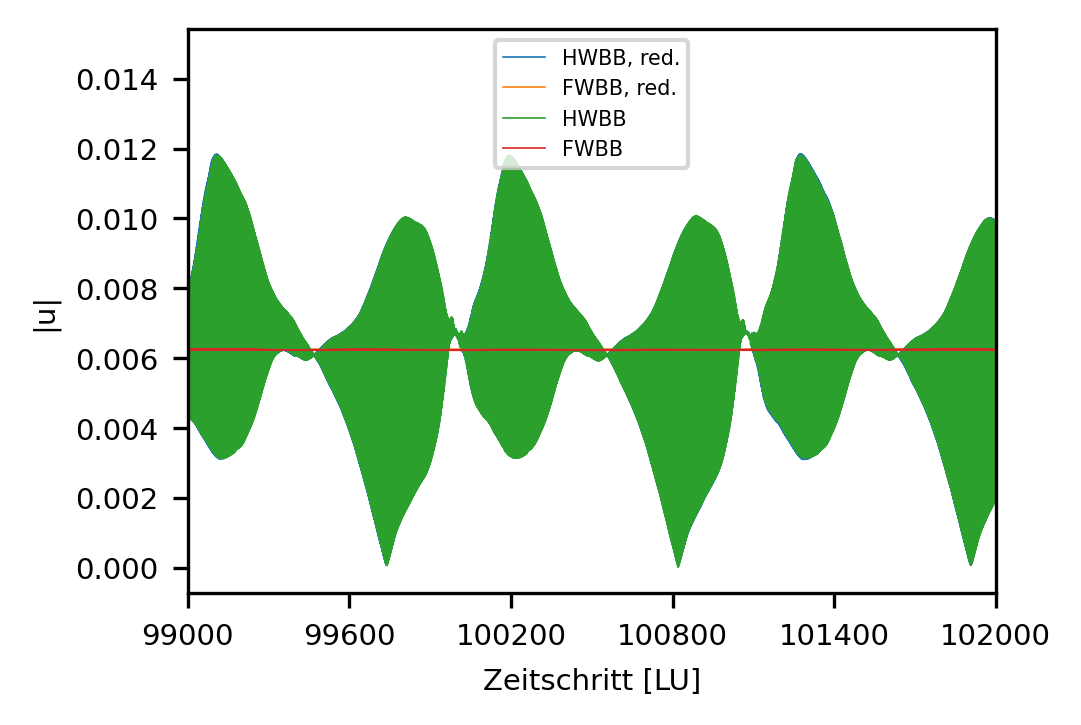

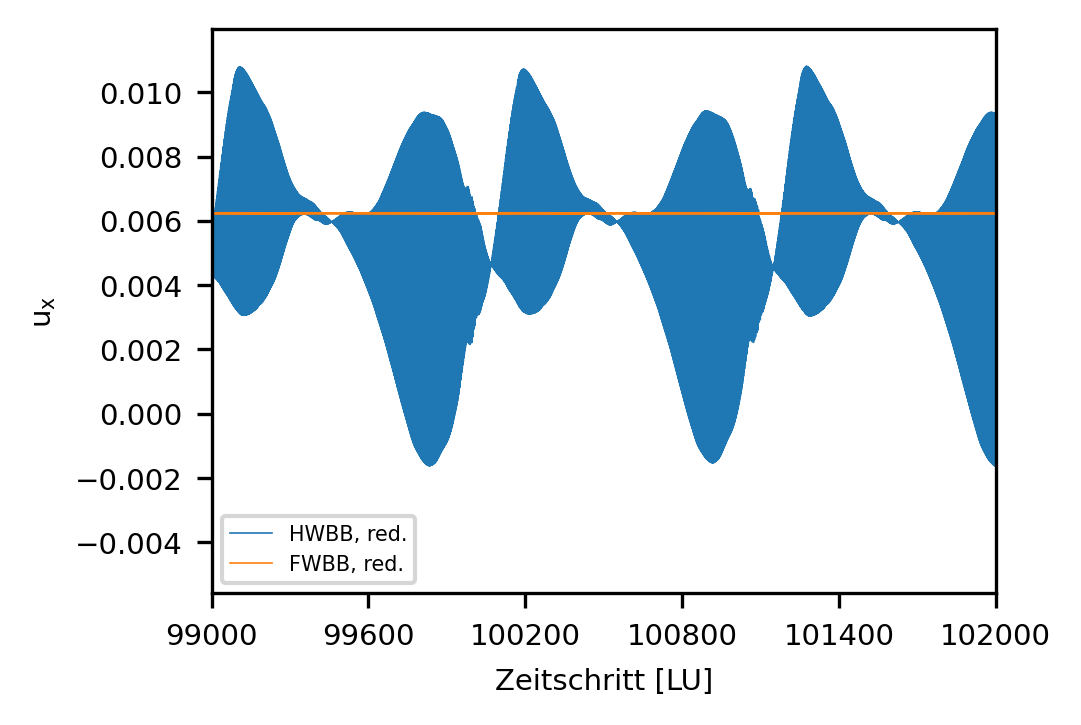

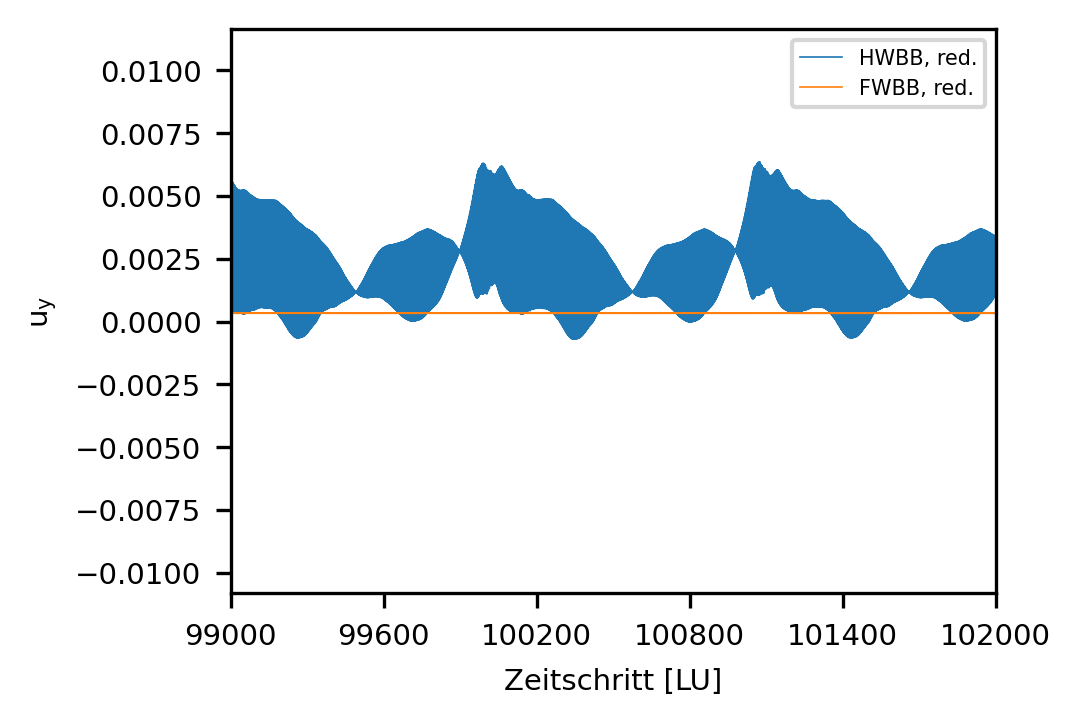

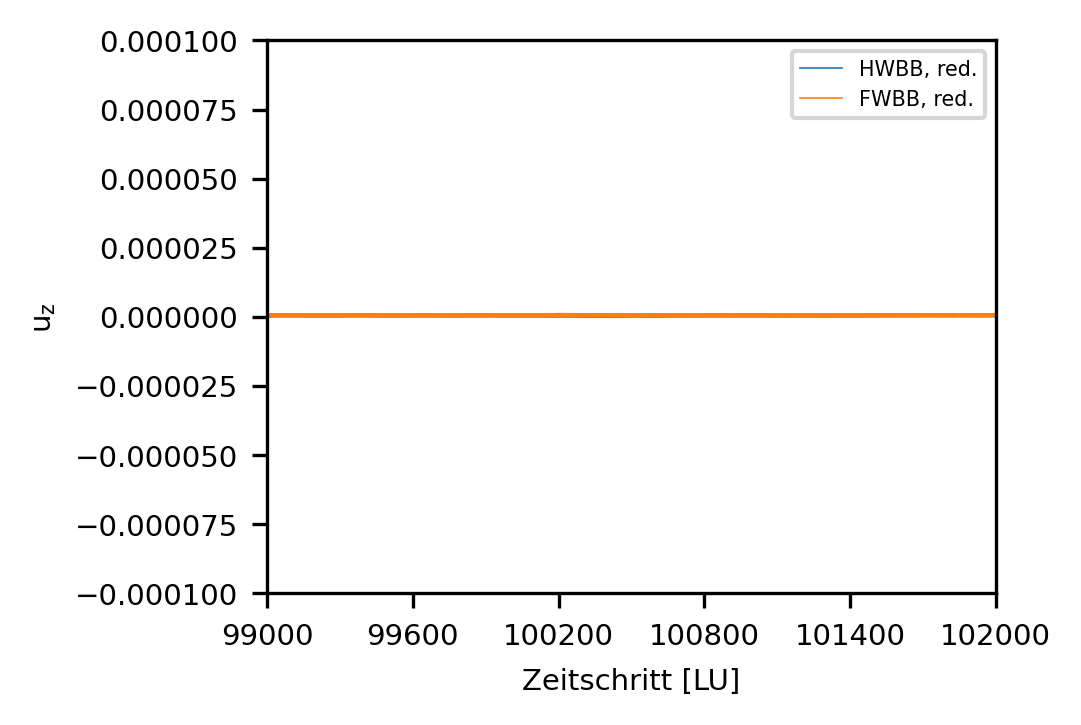

In [10]:
# plot again for zoomed section of x-axis... (time) to see oscillation

xlims = [[99900,100100], [99000,102000]]

# i, t, p, ux, uy, uz
# 0, 1, 2, 3 , 4 , 5

for xlim in xlims:

    xticks_list = np.linspace(xlim[0], xlim[1], 6)

    p_fig, p_axs = plt.subplots()
    p_axs.plot(pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB, red.")
    p_axs.plot(pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="FWBB, red.")
    p_axs.plot(pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"hwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="HWBB")
    p_axs.plot(pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,0], pu_timeseries_dict_ref[ma,re,"fwbb",x_position,y_position][:,2], marker="", linewidth=0.4, label="FWBB")

    p_axs.set_xlabel("Zeitschritt [LU]")
    #OLD: ax.set_ylim([0.7,1.7])  #TODO: mal "get" das Limit und dann mit 1e-4 vergleichen und das niedrigere nehmen.
    #p_axs.set_xlim(left=100)
    p_axs.set_xlim(xlim)  # full, 99900-100200, 99000-102000
    p_axs.set_xticks(xticks_list)
    p_axs.set_ylabel("p")
    p_axs.legend(fontsize=5)
    if plot_title:
        plt.suptitle("p(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + " _at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "p(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlim[0])+"-"+str(xlim[1]) + ".png")
    plt.show()
    #plt.close(p_fig)
    
    
    # u_mag
    u_fig, u_axs = plt.subplots()
    
    # reduced HWBB vs. FWBB
    u_axs.plot(data_reduced_hwbb[:,0], np.sqrt(np.square(data_reduced_hwbb[:, 3]) + np.square(data_reduced_hwbb[:, 4]) + np.square(data_reduced_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB, red.")
    u_axs.plot(data_reduced_fwbb[:,0], np.sqrt(np.square(data_reduced_fwbb[:, 3]) + np.square(data_reduced_fwbb[:, 4]) + np.square(data_reduced_fwbb[:, 5])), marker="", linewidth=0.4, label="FWBB, red.")
    # full HWBB vs. FWBB
    u_axs.plot(data_ref_hwbb[:,0], np.sqrt(np.square(data_ref_hwbb[:, 3]) + np.square(data_ref_hwbb[:, 4]) + np.square(data_ref_hwbb[:, 5])), marker="", linewidth=0.4, label="HWBB")
    u_axs.plot(data_ref_fwbb[:,0], np.sqrt(np.square(data_ref_fwbb[:, 3]) + np.square(data_ref_fwbb[:, 4]) + np.square(data_ref_fwbb[:, 5])), marker="", linewidth=0.4, label="FWBB")
    
    u_axs.set_xlabel("Zeitschritt [LU]")
    #u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #u_axs.set_xlim(left=100)
    #u_axs.set_xlim([9000,11000])
    u_axs.set_xlim(xlim)
    u_axs.set_xticks(xticks_list)
    u_axs.set_ylabel("|u|")
    u_axs.legend(fontsize=5)
    if plot_title:
        plt.suptitle("u_mag(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "u_mag(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlim[0])+"-"+str(xlim[1]) + ".png")
    plt.show()
    
    # ux
    u_fig, u_axs = plt.subplots()
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="HWBB, red.")
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 3], marker="", linewidth=0.4, label="FWBB, red.")
    
    
    
    u_axs.set_xlabel("Zeitschritt [LU]")
    #u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #u_axs.set_xlim(left=100)
    #u_axs.set_xlim([9000,11000])
    u_axs.set_xlim(xlim)
    u_axs.set_xticks(xticks_list)
    u_axs.set_ylabel(r"$\mathrm{u_x}$")
    u_axs.legend(fontsize=5)
    if plot_title:
        plt.suptitle("ux(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "ux(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlim[0])+"-"+str(xlim[1]) + ".png")
    plt.show()
    
    # uy
    u_fig, u_axs = plt.subplots()
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="HWBB, red.")
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 4], marker="", linewidth=0.4, label="FWBB, red.")
    
    
    
    u_axs.set_xlabel("Zeitschritt [LU]")
    #u_axs.set_ylim([0,0.1])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #u_axs.set_xlim(left=100)
    #u_axs.set_xlim([9000,11000])
    u_axs.set_xlim(xlim)
    u_axs.set_xticks(xticks_list)
    u_axs.set_ylabel(r"$\mathrm{u_y}$")
    u_axs.legend(fontsize=5)
    if plot_title:
        plt.suptitle("uy(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "uy(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlim[0])+"-"+str(xlim[1]) + ".png")
    plt.show()
    
    # uz
    u_fig, u_axs = plt.subplots()
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"hwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="HWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="HWBB, red.")
    
    data_reduced = pu_timeseries_dict_reduced[ma,re,"fwbb",x_position,y_position]
    # u_axs.plot(data_ref[:,0], np.sqrt(np.square(data_ref[:, 3]) + np.square(data_ref[:, 4]) + np.square(data_ref[:, 5])), marker="", linewidth=0.4, label="FWBB")
    u_axs.plot(data_reduced[:,0], data_reduced[:, 5], marker="", linewidth=0.4, label="FWBB, red.")
    
    
    
    u_axs.set_xlabel("Zeitschritt [LU]")
    u_axs.set_ylim([-0.0001,0.0001])  # bildet die super hohen HWBB-Geschwindigkeiten beim crash nicht voll ab
    #u_axs.set_xlim(left=100)
    #u_axs.set_xlim([9000,11000])
    u_axs.set_xlim(xlim)
    u_axs.set_xticks(xticks_list)
    u_axs.set_ylabel(r"$\mathrm{u_z}$")
    u_axs.legend(fontsize=5)
    if plot_title:
        plt.suptitle("uz(t) for Ma" + str(ma)  + "_Re" + str(re) + "_BC_" + gbc + " at " + "LU("+str(x_position)+" ," + str(y_position)+")")
    plt.savefig("/home/mbille/lettuce/plotting_MA/plots/" + plotting_batch_label + "uz(t)_Ma" + str(ma)  + "_Re" + str(re) + "_BC" + gbc + "_" + "LU("+str(x_position)+"," + str(y_position)+")_" + str(xlim[0])+"-"+str(xlim[1]) + ".png")
    plt.show()

In [10]:
#todo: Plots in zweimal 3x2 basteln mit individuellen Achsen
# - ALTERNATIV: eine Version mit 2x3 Plot mit vereinten Achsen